# 可选实验：特征工程与多项式回归

![](./images/C1_W2_Lab07_FeatureEngLecture.PNG)

## 目标
在本实验中，你将：
- 探索特征工程和多项式回归，它们使你能够利用线性回归机制来拟合非常复杂、甚至高度非线性的函数。

## 工具
你将使用先前实验中开发的函数，以及 Matplotlib 和 NumPy。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from lab_utils_multi import zscore_normalize_features, run_gradient_descent_feng
np.set_printoptions(precision=2)  # reduced display precision on numpy arrays

<a name='FeatureEng'></a>
# 特征工程与多项式回归概述

线性回归本身可以构建如下形式的模型：
$$f_{\mathbf{w},b} = w_0x_0 + w_1x_1+ ... + w_{n-1}x_{n-1} + b \tag{1}$$ 
如果特征/数据是非线性的，或者由多个特征组合而成，该怎么办？例如，房价与居住面积之间通常不是线性关系，而面积过小或过大的房屋都会受到影响，因而形成上图所示的曲线。如何利用线性回归机制来拟合这条曲线？回顾一下，我们拥有的“机制”是调整 (1) 中参数 $\mathbf{w}$、$\mathbf{b}$ 的能力，从而使方程“拟合”训练数据。然而，无论如何调整 (1) 中的 $\mathbf{w}$、$\mathbf{b}$，都无法拟合非线性曲线。

<a name='PolynomialFeatures'></a>
## 多项式特征

上面考虑的是数据呈非线性的情形。让我们利用目前掌握的知识来拟合一条非线性曲线。先从简单的二次式开始：$y = 1+x^2$

这里使用的例程您都已经熟悉，可以在 lab_utils.py 文件中查看。我们将使用 [`np.c_[..]`](https://numpy.org/doc/stable/reference/generated/numpy.c_.html)，这是一个沿列边界拼接的 NumPy 例程。

Iteration         0, Cost: 1.65756e+03
Iteration       100, Cost: 6.94549e+02
Iteration       200, Cost: 5.88475e+02
Iteration       300, Cost: 5.26414e+02
Iteration       400, Cost: 4.90103e+02
Iteration       500, Cost: 4.68858e+02
Iteration       600, Cost: 4.56428e+02
Iteration       700, Cost: 4.49155e+02
Iteration       800, Cost: 4.44900e+02
Iteration       900, Cost: 4.42411e+02
w,b found by gradient descent: w: [18.7], b: -52.0834


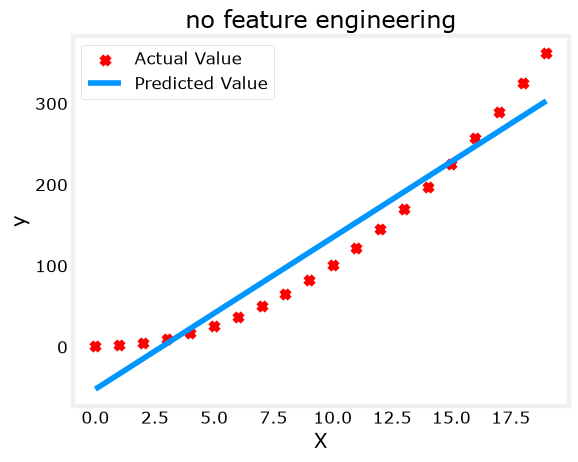

In [11]:
# create target data
x = np.arange(0, 20, 1)
y = 1 + x**2
X = x.reshape(-1, 1)

model_w,model_b = run_gradient_descent_feng(X,y,iterations=1000, alpha = 1e-2)

plt.scatter(x, y, marker='x', c='r', label="Actual Value"); plt.title("no feature engineering")
plt.plot(x,X@model_w + model_b, label="Predicted Value");  plt.xlabel("X"); plt.ylabel("y"); plt.legend(); plt.show()

嗯，正如预期，拟合效果不佳。我们需要类似 $y= w_0x_0^2 + b$ 的东西，也就是一个**多项式特征**。
为此，可以修改*输入数据*，通过*特征工程*构造所需特征。如果将原始数据替换为对 $x$ 值取平方的版本，就可以得到 $y= w_0x_0^2 + b$。来试试看。请在下面用 `X**2` 替换 `X`：

In [12]:
# create target data
x = np.arange(0, 20, 1)
y = 1 + x**2

# Engineer features 
X = x**2      #<-- added engineered feature

Iteration         0, Cost: 7.32922e+03
Iteration      1000, Cost: 2.24844e-01
Iteration      2000, Cost: 2.22795e-01
Iteration      3000, Cost: 2.20764e-01
Iteration      4000, Cost: 2.18752e-01
Iteration      5000, Cost: 2.16758e-01
Iteration      6000, Cost: 2.14782e-01
Iteration      7000, Cost: 2.12824e-01
Iteration      8000, Cost: 2.10884e-01
Iteration      9000, Cost: 2.08962e-01
w,b found by gradient descent: w: [1.], b: 0.0490


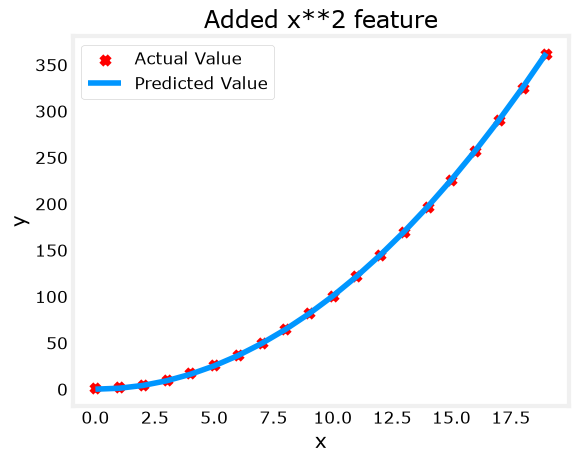

In [13]:
X = X.reshape(-1, 1)  #X should be a 2-D Matrix
model_w,model_b = run_gradient_descent_feng(X, y, iterations=10000, alpha = 1e-5)

plt.scatter(x, y, marker='x', c='r', label="Actual Value"); plt.title("Added x**2 feature")
plt.plot(x, np.dot(X,model_w) + model_b, label="Predicted Value"); plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.show()

太棒了！拟合几乎完美。请注意图像正上方打印的 $\mathbf{w}$ 和 b 的值：`w,b found by gradient descent: w: [1.], b: 0.0490`。梯度下降将 $\mathbf{w},b $ 的初始值修改为 (1.0,0.049)，即得到模型 $y=1*x_0^2+0.049$，这与目标 $y=1*x_0^2+1$ 非常接近。如果运行更长时间，拟合效果还会更好。

### 选择特征
<a name='GDF'></a>
上面，我们知道需要一个 $x^2$ 项。但所需的特征并不总是显而易见。可以加入各种候选特征，尝试找出最有用的特征。例如，如果我们改为尝试 $y=w_0x_0 + w_1x_1^2 + w_2x_2^3+b$，结果会怎样？

运行接下来的单元格。

In [14]:
# create target data
x = np.arange(0, 20, 1)
y = x**2

# engineer features .
X = np.c_[x, x**2, x**3]   #<-- added engineered feature

Iteration         0, Cost: 1.14029e+03
Iteration      1000, Cost: 3.28539e+02
Iteration      2000, Cost: 2.80443e+02
Iteration      3000, Cost: 2.39389e+02
Iteration      4000, Cost: 2.04344e+02
Iteration      5000, Cost: 1.74430e+02
Iteration      6000, Cost: 1.48896e+02
Iteration      7000, Cost: 1.27100e+02
Iteration      8000, Cost: 1.08495e+02
Iteration      9000, Cost: 9.26132e+01
w,b found by gradient descent: w: [0.08 0.54 0.03], b: 0.0106


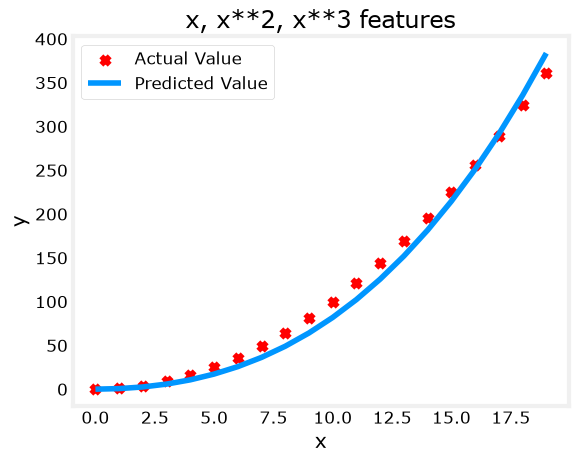

In [15]:
model_w,model_b = run_gradient_descent_feng(X, y, iterations=10000, alpha=1e-7)

plt.scatter(x, y, marker='x', c='r', label="Actual Value"); plt.title("x, x**2, x**3 features")
plt.plot(x, X@model_w + model_b, label="Predicted Value"); plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.show()

请注意，$\mathbf{w}$、`[0.08 0.54 0.03]` 和 b 的值为 `0.0106`。这意味着拟合/训练后的模型为：
$$ 0.08x + 0.54x^2 + 0.03x^3 + 0.0106 $$
梯度下降通过增大 $w_1$ 项相对于其他项的权重，强调了最适合 $x^2$ 数据的特征。如果运行很长时间，它会继续减小其他项的影响。
>梯度下降通过强调与特征关联的参数，帮助我们选择“正确”的特征

让我们回顾一下这个思路：
- 首先，对特征进行了重新缩放，使它们彼此可比
- 权重值越小，意味着特征越不重要或越不正确；在极端情况下，当权重变为零或非常接近零时，相关特征对数据的模型拟合几乎没有用处。
- 在上面的拟合之后，与 $x^2$ 特征关联的权重远大于 $x$ 或 $x^3$ 的权重，因为它对拟合数据最有用。

### 另一种视角
上面根据多项式特征与目标数据的匹配程度选择了特征。另一种理解方式是：创建新特征后，我们仍然在使用线性回归。因此，最佳特征相对于目标应呈线性关系。通过示例最容易理解这一点。

In [16]:
# create target data
x = np.arange(0, 20, 1)
y = x**2

# engineer features .
X = np.c_[x, x**2, x**3]   #<-- added engineered feature
X_features = ['x','x^2','x^3']

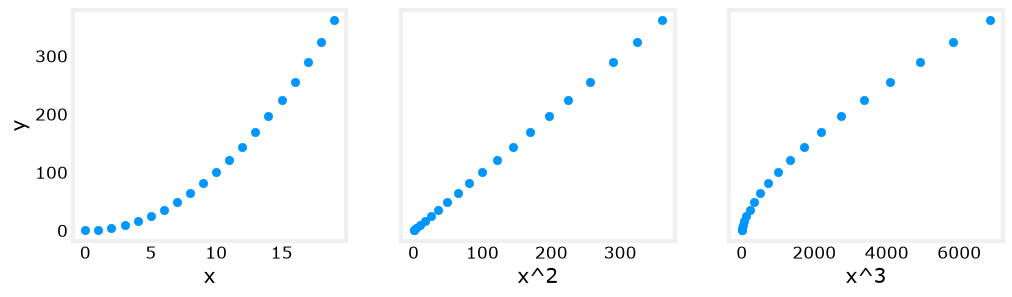

In [17]:
fig,ax=plt.subplots(1, 3, figsize=(12, 3), sharey=True)
for i in range(len(ax)):
    ax[i].scatter(X[:,i],y)
    ax[i].set_xlabel(X_features[i])
ax[0].set_ylabel("y")
plt.show()

上图清楚地表明，映射到目标值 $y$ 的 $x^2$ 特征呈线性关系。因此，线性回归可以很容易地使用该特征生成模型。

### 特征缩放
如上一个实验所述，如果数据集中的特征尺度差异显著，应进行特征缩放以加快梯度下降。在上面的示例中，$x$、$x^2$ 和 $x^3$ 的尺度自然会有很大差异。让我们对这个示例应用 Z-score 标准化。

In [19]:
# create target data
x = np.arange(0,20,1)
X = np.c_[x, x**2, x**3]
print(f"Peak to Peak range by column in Raw        X:{np.ptp(X,axis=0)}")

# add mean_normalization 
X = zscore_normalize_features(X)     
print(f"Peak to Peak range by column in Normalized X:{np.ptp(X,axis=0)}")

Peak to Peak range by column in Raw        X:[  19  361 6859]
Peak to Peak range by column in Normalized X:[3.3  3.18 3.28]


现在，我们可以使用更激进的 alpha 值再试一次：

Iteration         0, Cost: 9.42147e+03
Iteration     10000, Cost: 3.90938e-01
Iteration     20000, Cost: 2.78389e-02
Iteration     30000, Cost: 1.98242e-03
Iteration     40000, Cost: 1.41169e-04
Iteration     50000, Cost: 1.00527e-05
Iteration     60000, Cost: 7.15855e-07
Iteration     70000, Cost: 5.09763e-08
Iteration     80000, Cost: 3.63004e-09
Iteration     90000, Cost: 2.58497e-10
w,b found by gradient descent: w: [5.27e-05 1.13e+02 8.43e-05], b: 123.5000


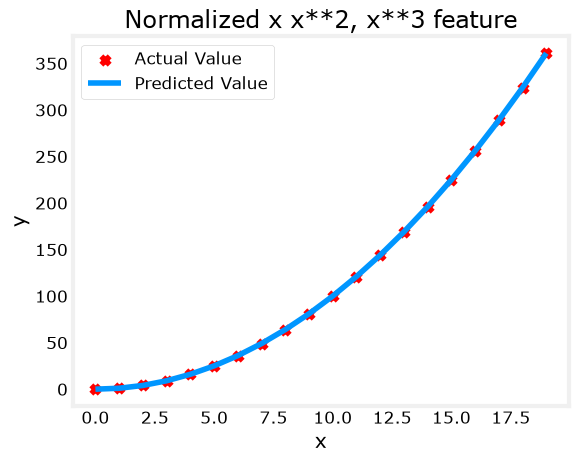

In [20]:
x = np.arange(0,20,1)
y = x**2

X = np.c_[x, x**2, x**3]
X = zscore_normalize_features(X) 

model_w, model_b = run_gradient_descent_feng(X, y, iterations=100000, alpha=1e-1)

plt.scatter(x, y, marker='x', c='r', label="Actual Value"); plt.title("Normalized x x**2, x**3 feature")
plt.plot(x,X@model_w + model_b, label="Predicted Value"); plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.show()

特征缩放使其收敛快得多。  
再次注意 $\mathbf{w}$ 的值。作为 $x^2$ 项的 $w_1$ 项受到的影响最大。梯度下降几乎完全消除了 $x^3$ 项。

### 复杂函数
借助特征工程，即使相当复杂的函数也可以建模：

Iteration         0, Cost: 2.20188e-01
Iteration    100000, Cost: 1.70074e-02
Iteration    200000, Cost: 1.27603e-02
Iteration    300000, Cost: 9.73032e-03
Iteration    400000, Cost: 7.56440e-03
Iteration    500000, Cost: 6.01412e-03
Iteration    600000, Cost: 4.90251e-03
Iteration    700000, Cost: 4.10351e-03
Iteration    800000, Cost: 3.52730e-03
Iteration    900000, Cost: 3.10989e-03
w,b found by gradient descent: w: [ -1.34 -10.    24.78   5.96 -12.49 -16.26  -9.51   0.59   8.7   11.94
   9.27   0.79 -12.82], b: -0.0073


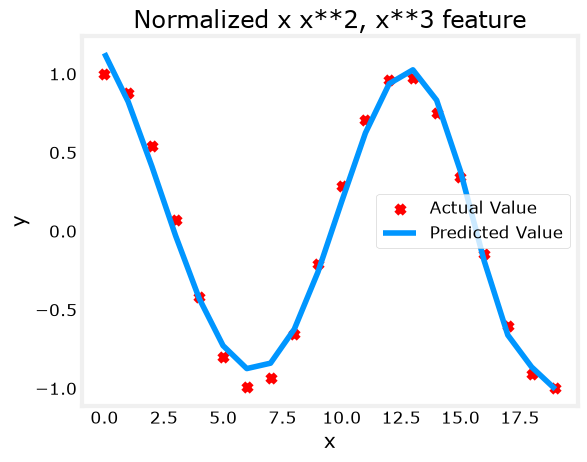

In [21]:
x = np.arange(0,20,1)
y = np.cos(x/2)

X = np.c_[x, x**2, x**3,x**4, x**5, x**6, x**7, x**8, x**9, x**10, x**11, x**12, x**13]
X = zscore_normalize_features(X) 

model_w,model_b = run_gradient_descent_feng(X, y, iterations=1000000, alpha = 1e-1)

plt.scatter(x, y, marker='x', c='r', label="Actual Value"); plt.title("Normalized x x**2, x**3 feature")
plt.plot(x,X@model_w + model_b, label="Predicted Value"); plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.show()



## 恭喜！
在本实验中，你：
- 学习了线性回归如何借助特征工程对复杂乃至高度非线性的函数进行建模
- 认识到在进行特征工程时，应用特征缩放非常重要